# Outlier Handling

An outlier is an observation that lies unusually far from the rest of the data.

The Interquartile Range (IQR) method is used to identify potential outliers in the transaction amount (`amt`) feature.

# Credit Card Fraud Detection
## Outlier Handling

This notebook focuses on identifying and handling outliers in the credit card fraud dataset using the Interquartile Range (IQR) method.

### Steps:
1. Import libraries
2. Load the dataset
3. Understand the dataset
4. Analyze transaction amount
5. Detect outliers using IQR
6. Remove outliers
7. Handle outliers using capping
8. Compare the results

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Load the Dataset

The `fraudTrain.csv` dataset is loaded for outlier analysis.

In [4]:
df = pd.read_csv("../archive (2)/fraudTrain.csv")

## 2. View the Dataset

Display the first few records to understand the structure of the dataset.

In [5]:
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


## 3. Dataset Information

Check the number of rows, columns, data types, and other basic information.

In [6]:
print("Dataset Shape:", df.shape)

df.info()

Dataset Shape: (1296675, 23)
<class 'pandas.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  str    
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  str    
 4   category               1296675 non-null  str    
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  str    
 7   last                   1296675 non-null  str    
 8   gender                 1296675 non-null  str    
 9   street                 1296675 non-null  str    
 10  city                   1296675 non-null  str    
 11  state                  1296675 non-null  str    
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  

## 4. Statistical Summary

Display statistical information for the numerical features.

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,1296675.0,6.483370e+05,3.743180e+05,0.000000e+00,3.241685e+05,6.483370e+05,9.725055e+05,1.296674e+06
cc_num,1296675.0,4.171920e+17,1.308806e+18,6.041621e+10,1.800429e+14,3.521417e+15,4.642255e+15,4.992346e+18
amt,1296675.0,7.035104e+01,1.603160e+02,1.000000e+00,9.650000e+00,4.752000e+01,8.314000e+01,2.894890e+04
zip,1296675.0,4.880067e+04,2.689322e+04,1.257000e+03,2.623700e+04,4.817400e+04,7.204200e+04,9.978300e+04
lat,1296675.0,3.853762e+01,5.075808e+00,2.002710e+01,3.462050e+01,3.935430e+01,4.194040e+01,6.669330e+01
long,1296675.0,-9.022634e+01,1.375908e+01,-1.656723e+02,-9.679800e+01,-8.747690e+01,-8.015800e+01,-6.795030e+01
city_pop,1296675.0,8.882444e+04,3.019564e+05,2.300000e+01,7.430000e+02,2.456000e+03,2.032800e+04,2.906700e+06
unix_time,1296675.0,1.349244e+09,1.284128e+07,1.325376e+09,1.338751e+09,1.349250e+09,1.359385e+09,1.371817e+09
merch_lat,1296675.0,3.853734e+01,5.109788e+00,1.902779e+01,3.473357e+01,3.936568e+01,4.195716e+01,6.751027e+01
merch_long,1296675.0,-9.022646e+01,1.377109e+01,-1.666712e+02,-9.689728e+01,-8.743839e+01,-8.023680e+01,-6.695090e+01


## Justification for Selecting `amt` for Outlier Analysis

The original dataset is used to compare the numerical features before outlier handling.

The features are compared using skewness and the percentage of potential outliers identified using the IQR method. This provides a data-based justification for selecting `amt` for detailed outlier analysis.

In [21]:
# Load the original dataset so that previous outlier handling does not affect this analysis
original_df = pd.read_csv("../archive (2)/fraudTrain.csv")

numeric_cols = original_df.select_dtypes(include=np.number).columns

results = []

for col in numeric_cols:
    Q1 = original_df[col].quantile(0.25)
    Q3 = original_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = (
        (original_df[col] < lower_bound) |
        (original_df[col] > upper_bound)
    ).sum()

    outlier_percentage = (outlier_count / len(original_df)) * 100

    results.append({
        "Feature": col,
        "Skewness": original_df[col].skew(),
        "Outlier Count": outlier_count,
        "Outlier Percentage": outlier_percentage
    })

justification = pd.DataFrame(results)

justification.sort_values(
    by="Outlier Percentage",
    ascending=False
)

,Feature,Skewness,Outlier Count,Outlier Percentage
6,city_pop,5.593853e+00,242674,18.715098
1,cc_num,2.851879e+00,118789,9.161047
2,amt,4.227787e+01,67290,5.189427
5,long,-1.150108e+00,49922,3.850001
9,merch_long,-1.146960e+00,41994,3.238591
10,is_fraud,1.302912e+01,7506,0.578865
8,merch_lat,-1.819154e-01,4967,0.383057
4,lat,-1.860277e-01,4679,0.360846
0,Unnamed: 0,1.233496e-16,0,0.000000
3,zip,7.968076e-02,0,0.000000


## Visualization of the Selected Feature

A boxplot is used to visualize the distribution of the `amt` feature and identify potential extreme values.

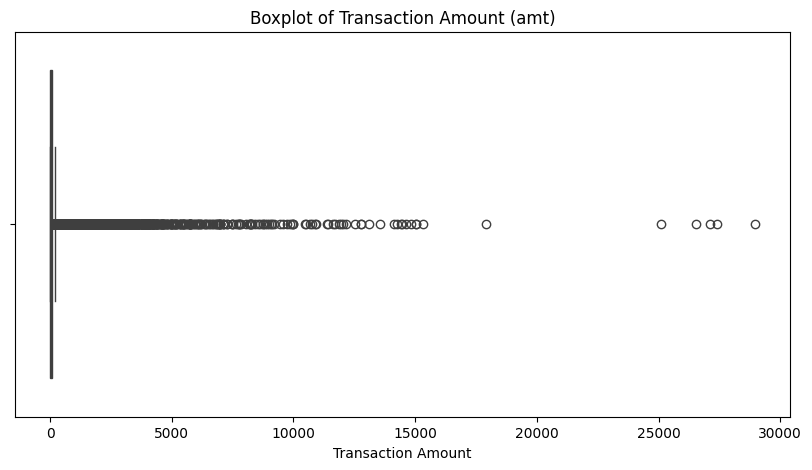

In [22]:
plt.figure(figsize=(10, 5))

sns.boxplot(x=original_df["amt"])

plt.title("Boxplot of Transaction Amount (amt)")
plt.xlabel("Transaction Amount")

plt.show()

# Outlier Detection Using IQR

An outlier is an observation that lies unusually far from the majority of the data.

The Interquartile Range (IQR) method is used to identify potential outliers in the transaction amount (`amt`) feature.

## 5. Analyze Transaction Amount

The `amt` column represents the transaction amount.

First, we examine its basic statistical properties.

In [8]:
df["amt"].describe()

count    1.296675e+06
mean     7.035104e+01
std      1.603160e+02
min      1.000000e+00
25%      9.650000e+00
50%      4.752000e+01
75%      8.314000e+01
max      2.894890e+04
Name: amt, dtype: float64

## 6. Calculate Q1 and Q3

Q1 is the 25th percentile.

Q3 is the 75th percentile.

In [10]:
Q1 = df["amt"].quantile(0.25)
Q3 = df["amt"].quantile(0.75)

print("Q1:", Q1)
print("Q3:", Q3)

Q1: 9.65
Q3: 83.14


## 7. Calculate IQR

The Interquartile Range is calculated using:

IQR = Q3 - Q1

In [11]:
IQR = Q3 - Q1

print("IQR:", IQR)

IQR: 73.49


## 8. Calculate Outlier Boundaries

The standard IQR method defines the boundaries as:

Lower Bound = Q1 - 1.5 × IQR

Upper Bound = Q3 + 1.5 × IQR

Values outside these boundaries are considered potential outliers.

In [12]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Lower Bound: -100.58499999999998
Upper Bound: 193.375


## 9. Identify Outliers

Transactions with an amount below the lower bound or above the upper bound are identified as potential outliers.

In [13]:
outliers = df[
    (df["amt"] < lower_bound) |
    (df["amt"] > upper_bound)
]

print("Number of outliers:", len(outliers))

Number of outliers: 67290


## 10. Calculate Outlier Percentage

In [14]:
outlier_percentage = (len(outliers) / len(df)) * 100

print("Outlier Percentage:", outlier_percentage, "%")

Outlier Percentage: 5.1894268031696456 %


## 11. View the Identified Outliers

The transaction amount and fraud status are displayed to examine the detected extreme transactions.

In [15]:
outliers[["amt", "is_fraud"]].head(20)

,amt,is_fraud
2,220.11,0
9,198.39,0
16,327.00,0
17,341.67,0
36,207.36,0
39,221.81,0
43,212.75,0
54,212.45,0
67,303.47,0
73,317.14,0


# Outlier Removal

In this method, observations with transaction amounts outside the IQR boundaries are removed from the dataset.

In [16]:
df_no_outliers = df[
    (df["amt"] >= lower_bound) &
    (df["amt"] <= upper_bound)
].copy()

## 12. Compare Dataset Before and After Removal

In [17]:
print("Original dataset shape:", df.shape)
print("Dataset after outlier removal:", df_no_outliers.shape)

print("Number of rows removed:", len(df) - len(df_no_outliers))

Original dataset shape: (1296675, 23)
Dataset after outlier removal: (1229385, 23)
Number of rows removed: 67290


# Outlier Capping

Instead of removing extreme observations, capping replaces values outside the IQR boundaries with the corresponding boundary values.

This preserves the number of observations in the dataset.

In [18]:
df["amt_capped"] = df["amt"].clip(
    lower=lower_bound,
    upper=upper_bound
)

## 13. Compare Original and Capped Values

In [19]:
print("Original Minimum:", df["amt"].min())
print("Capped Minimum:", df["amt_capped"].min())

print("Original Maximum:", df["amt"].max())
print("Capped Maximum:", df["amt_capped"].max())

Original Minimum: 1.0
Capped Minimum: 1.0
Original Maximum: 28948.9
Capped Maximum: 193.375


## 14. Compare Original and Capped Data

The original and capped transaction amounts are displayed side by side.

In [20]:
comparison = pd.DataFrame({
    "Original Amount": df["amt"],
    "Capped Amount": df["amt_capped"]
})

comparison.head(10)

,Original Amount,Capped Amount
0,4.97,4.970
1,107.23,107.230
2,220.11,193.375
3,45.00,45.000
4,41.96,41.960
5,94.63,94.630
6,44.54,44.540
7,71.65,71.650
8,4.27,4.270
9,198.39,193.375


# Conclusion

The credit card fraud training dataset was analyzed for potential outliers in the transaction amount (`amt`) feature.

The Interquartile Range (IQR) method was used to:

- Calculate Q1 and Q3
- Calculate the IQR
- Determine the lower and upper bounds
- Identify potential outliers
- Calculate the percentage of outliers

Two outlier handling techniques were demonstrated:

1. **Outlier Removal** – removes observations outside the IQR boundaries.
2. **Outlier Capping** – replaces extreme values with the corresponding boundary values.

In fraud detection, an extreme transaction amount is not necessarily an error. It may contain useful information for identifying fraudulent transactions. Therefore, outlier treatment should be selected carefully based on the requirements of the fraud detection model.